# Plotting Utilities Notebook

This notebook is the notebook version of `utils.py`, adapted to this repo layout. It reads Lotka--Volterra result `.npz` files from the project root, renders figures inline, and saves the main panel figure to `figures/lv_summary.pdf`.


In [92]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROOT = Path.cwd()
RESULTS_DIR = ROOT / "results" /"lv"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUT_FIGURE = FIGURES_DIR / "lv_summary.pdf"

plt.rcParams['axes.grid'] = True
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath, amsfonts, mathrsfs, amssymb}')

SUMMARY_FIGSIZE = (30, 6.5)
FIGSIZE = (6, 4)
DPI = 100
TITLE_SIZE = 24
LABEL_SIZE = 40
TICK_SIZE = 30
LEGEND_SIZE = 40
MARKER_SIZE = 60
COMPARISON_SCATTER_SIZE = 28
LINE_WIDTH = 2.0
TITLE_PAD = 8
FOUR_PANEL_LEGEND_SIZE = 32
COLORS = {
        "gd": "#1b9e77",
        "pgd": "#d95f02",
        "truth": "#f4b400",
    }
CORRUPTION_LINESTYLES = {
    "clean": "-",
    "0": "-",
    "15": "--",
    "35": ":",
}

BASE_PLOT_RC = {
    "axes.grid": True,
    "font.family": "DejaVu Serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amsfonts, mathrsfs, amssymb}",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": LINE_WIDTH,
    "lines.markersize": MARKER_SIZE,
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
}
LOCAL_PLOT_RC = dict(BASE_PLOT_RC)
plt.rcParams.update(BASE_PLOT_RC)
ROOT, RESULTS_DIR, OUTPUT_FIGURE

(PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL'),
 PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv'),
 PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_summary.pdf'))

In [93]:
def _load_npz_dict(npz_path):
    npz_path = Path(npz_path)
    with np.load(npz_path) as data:
        return {key: data[key] for key in data.files}


def _save_figure(fig, output_path=None, **savefig_kwargs):
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, **savefig_kwargs)
    return fig


def _lv_plot_branch(ax, hist, color, markevery, start_marker_color=None, start_marker="o", start_marker_size=220):
    ax.plot(hist[:, 0], hist[:, 1], color=color, marker="o", markevery=markevery, markersize=5.0)
    if start_marker_color is None:
        start_marker_color = "white"
    ax.scatter(
        hist[0, 0],
        hist[0, 1],
        color=start_marker_color,
        marker=start_marker,
        edgecolors="none",
        linewidths=0.0,
        s=start_marker_size,
        zorder=5,
    )
    ax.scatter(hist[-1, 0], hist[-1, 1], color=color, marker="s", s=48, zorder=5)


def _lv_draw_theta12_trajectory(ax, npz_paths, show_true=True, init_markers=None, init_colors=None):
    path_colors = [
        (COLORS["gd"], COLORS["pgd"]),
        (COLORS["gd"], COLORS["pgd"]),
    ]
    if init_markers is None:
        init_markers = ["o", "^", "D", "v"]
    if init_colors is None:
        init_colors = ["#7B3294", "#4D4D4D", "#7B3294", "#4D4D4D"]

    theta_true = None
    for idx, npz_path in enumerate(npz_paths):
        data = _load_npz_dict(npz_path)
        sgd = np.asarray(data["sgd_theta_history_mean"], dtype=float)[:, :2]
        pgd = np.asarray(data["pgd_theta_history_mean"], dtype=float)[:, :2]
        theta_true = np.asarray(data["theta_true"], dtype=float)
        sgd_color, pgd_color = path_colors[min(idx, len(path_colors) - 1)]
        init_marker = init_markers[idx % len(init_markers)]
        init_color = init_colors[idx % len(init_colors)]
        _lv_plot_branch(ax, sgd, sgd_color, max(1, len(sgd) // 22), start_marker_color=init_color, start_marker=init_marker)
        _lv_plot_branch(ax, pgd, pgd_color, max(1, len(pgd) // 22), start_marker_color=init_color, start_marker=init_marker)

    if show_true and theta_true is not None:
        ax.scatter(theta_true[0], theta_true[1], marker="*", s=900, color=COLORS["truth"], zorder=6)

    ax.set_xlabel(r"Parameter 1 ($\theta_1$)")
    ax.set_ylabel(r"Parameter 2 ($\theta_2$)")
    ax.grid(True, alpha=0.24, linewidth=0.8)


def make_lv_theta_trajectory_plot(npz_paths, output_path=None, show_true=True):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(5.2, 4.9), dpi=150)
        _lv_draw_theta12_trajectory(ax, npz_paths, show_true=show_true)
        fig.tight_layout()
        return _save_figure(fig, output_path)


def _lv_draw_history_panel(
    ax,
    bundles,
    param_idx,
    ylabel,
    true_theta,
    show_xlabel=True,
    se_scale=1.96,
    true_only=True,
    init_markers=None,
    init_colors=None,
):
    for idx, (data, color_sgd, color_pgd, ls_sgd, ls_pgd) in enumerate(bundles):
        sgd_steps = np.asarray(data["sgd_history_steps"], dtype=float) + 1.0
        pgd_steps = np.asarray(data["pgd_history_steps"], dtype=float) + 1.0
        sgd_hist = np.asarray(data["sgd_theta_histories"], dtype=float)[:, :, param_idx]
        pgd_hist = np.asarray(data["pgd_theta_histories"], dtype=float)[:, :, param_idx]

        sgd_mean = sgd_hist.mean(axis=0)
        pgd_mean = pgd_hist.mean(axis=0)
        sgd_se = sgd_hist.std(axis=0, ddof=0) / np.sqrt(max(sgd_hist.shape[0], 1))
        pgd_se = pgd_hist.std(axis=0, ddof=0) / np.sqrt(max(pgd_hist.shape[0], 1))
        init_marker = None if init_markers is None else init_markers[idx % len(init_markers)]
        init_color = None if init_colors is None else init_colors[idx % len(init_colors)]

        ax.plot(
            sgd_steps,
            sgd_mean,
            color=color_sgd,
            linestyle=ls_sgd,
            linewidth=2.0,
            marker=None,
        )
        ax.fill_between(
            sgd_steps,
            sgd_mean - se_scale * sgd_se,
            sgd_mean + se_scale * sgd_se,
            color=color_sgd,
            alpha=0.12,
        )
        ax.plot(
            pgd_steps,
            pgd_mean,
            color=color_pgd,
            linestyle=ls_pgd,
            linewidth=2.0,
            marker=None,
        )
        ax.fill_between(
            pgd_steps,
            pgd_mean - se_scale * pgd_se,
            pgd_mean + se_scale * pgd_se,
            color=color_pgd,
            alpha=0.12,
        )
        if init_marker is not None:
            marker_color = init_color if init_color is not None else "white"
            ax.scatter(
                sgd_steps[0],
                sgd_mean[0],
                color=marker_color,
                marker=init_marker,
                edgecolors="none",
                linewidths=0.0,
                s=220,
                zorder=5,
            )
            ax.scatter(
                pgd_steps[0],
                pgd_mean[0],
                color=marker_color,
                marker=init_marker,
                edgecolors="none",
                linewidths=0.0,
                s=220,
                zorder=5,
            )

    if true_only:
        ax.axhline(float(true_theta[param_idx]), color="0.35", linestyle="--", linewidth=1.2)

    ax.set_xscale("log")
    ax.set_xlabel("Iteration" if show_xlabel else "")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="major", alpha=0.28, linewidth=0.8)


def make_lv_param_history_plot_from_npz(
    npz_path,
    param_idx,
    output_path=None,
    se_scale=1.96,
    solid_for_both=True,
    true_only=True,
    show_xlabel=True,
):
    data = _load_npz_dict(npz_path)
    bundles = [
        (
            data,
            COLORS["gd"],
            COLORS["pgd"],
            "-" if solid_for_both else "--",
            "-",
        )
    ]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.1, 4.8), dpi=150)
        _lv_draw_history_panel(
            ax,
            bundles,
            param_idx=param_idx,
            ylabel=rf"$\theta_{param_idx + 1}$",
            true_theta=np.asarray(data["theta_true"], dtype=float),
            show_xlabel=show_xlabel,
            se_scale=se_scale,
            true_only=true_only,
        )
        fig.tight_layout()
        return _save_figure(fig, output_path)


def make_lv_dual_init_history_plot(
    npz_paths,
    param_idx,
    output_path=None,
    figsize=(6, 2),
    dpi=100,
    se_scale=1.96,
):
    bundles = []
    for idx, npz_path in enumerate(npz_paths):
        data = _load_npz_dict(npz_path)
        if idx == 0:
            bundles.append((data, COLORS["gd"], COLORS["pgd"], "-", "-"))
        else:
            bundles.append((data, COLORS["gd"], COLORS["pgd"], "--", "--"))

    true_theta = np.asarray(bundles[0][0]["theta_true"], dtype=float)
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        _lv_draw_history_panel(
            ax,
            bundles,
            param_idx=param_idx,
            ylabel=rf"$\theta_{param_idx + 1}$",
            true_theta=true_theta,
            show_xlabel=True,
            se_scale=se_scale,
            true_only=True,
        )
        fig.tight_layout()
        return _save_figure(fig, output_path)


def make_lv_corruption_history_plot(
    npz_paths,
    param_idx,
    output_path=None,
    figsize=(6, 2),
    dpi=100,
    se_scale=1.96,
):
    bundles = []
    for idx, npz_path in enumerate(npz_paths):
        data = _load_npz_dict(npz_path)
        corruption_key = "15" if idx == 0 else "35"
        ls = CORRUPTION_LINESTYLES[corruption_key]
        bundles.append((data, COLORS["gd"], COLORS["pgd"], ls, ls))

    true_theta = np.asarray(bundles[0][0]["theta_true"], dtype=float)
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        _lv_draw_history_panel(
            ax,
            bundles,
            param_idx=param_idx,
            ylabel=rf"$\theta_{param_idx + 1}$",
            true_theta=true_theta,
            show_xlabel=True,
            se_scale=se_scale,
            true_only=True,
        )
        fig.tight_layout()
        return _save_figure(fig, output_path)


def make_lv_five_panel_summary(
    clean_npz_paths,
    corruption_npz_paths,
    output_path=None,
    figsize=(24, 5),
    dpi=100,
    se_scale=1.96,
):
    clean_data = [_load_npz_dict(path) for path in clean_npz_paths]
    cor_data = [_load_npz_dict(path) for path in corruption_npz_paths]
    theta_true = np.asarray(clean_data[0]["theta_true"], dtype=float)
    init_markers = ["o", "^"]
    init_colors = ["#7B3294", "#4D4D4D"]

    with plt.rc_context(LOCAL_PLOT_RC):
        fig = plt.figure(figsize=figsize, dpi=dpi)
        gs = fig.add_gridspec(2, 3, width_ratios=[1.0, 1.05, 1.05], wspace=0.24, hspace=0.20)
        ax_traj = fig.add_subplot(gs[:, 0])
        ax_clean_1 = fig.add_subplot(gs[0, 1])
        ax_clean_2 = fig.add_subplot(gs[1, 1])
        ax_cor_1 = fig.add_subplot(gs[0, 2])
        ax_cor_2 = fig.add_subplot(gs[1, 2])

        _lv_draw_theta12_trajectory(ax_traj, clean_npz_paths, show_true=True, init_markers=init_markers, init_colors=init_colors)

        clean_bundles = [
            (clean_data[0], COLORS["gd"], COLORS["pgd"], CORRUPTION_LINESTYLES["0"], CORRUPTION_LINESTYLES["0"]),
            (clean_data[1], COLORS["gd"], COLORS["pgd"], CORRUPTION_LINESTYLES["0"], CORRUPTION_LINESTYLES["0"]),
        ]
        cor_bundles = [
            (cor_data[0], COLORS["gd"], COLORS["pgd"], CORRUPTION_LINESTYLES["15"], CORRUPTION_LINESTYLES["15"]),
            (cor_data[1], COLORS["gd"], COLORS["pgd"], CORRUPTION_LINESTYLES["35"], CORRUPTION_LINESTYLES["35"]),
        ]

        _lv_draw_history_panel(ax_clean_1, clean_bundles, 0, r"$\theta_1$", theta_true, show_xlabel=False, se_scale=se_scale, init_markers=init_markers, init_colors=init_colors)
        _lv_draw_history_panel(ax_clean_2, clean_bundles, 1, r"$\theta_2$", theta_true, show_xlabel=True, se_scale=se_scale, init_markers=init_markers, init_colors=init_colors)
        _lv_draw_history_panel(ax_cor_1, cor_bundles, 0, r"$\theta_1$", theta_true, show_xlabel=False, se_scale=se_scale)
        _lv_draw_history_panel(ax_cor_2, cor_bundles, 1, r"$\theta_2$", theta_true, show_xlabel=True, se_scale=se_scale)
        ax_clean_1.set_xticks([])
        ax_cor_1.set_xticks([])

        left_handles = [
            Line2D([0], [0], color=COLORS["gd"], linestyle="-", linewidth=2.2, label="GD"),
            Line2D([0], [0], color=COLORS["pgd"], linestyle="-", linewidth=2.2, label="PGD"),
        ]
        right_handles = [
            Line2D([0], [0], color="black", linestyle=CORRUPTION_LINESTYLES["0"], linewidth=2.2, label="0\%"),
            Line2D([0], [0], color="black", linestyle=CORRUPTION_LINESTYLES["15"], linewidth=2.2, label="15\%"),
            Line2D([0], [0], color="black", linestyle=CORRUPTION_LINESTYLES["35"], linewidth=2.2, label="35\%"),
        ]

        fig.legend(
            left_handles,
            [h.get_label() for h in left_handles],
            loc="upper left",
            bbox_to_anchor=(0.09, 1.06),
            ncol=2,
            frameon=False,
            fontsize=48,
            handlelength=2.2,
            columnspacing=1.4,
            handletextpad=0.6,
        )
        fig.legend(
            right_handles,
            [h.get_label() for h in right_handles],
            loc="upper right",
            bbox_to_anchor=(0.92, 1.03),
            ncol=3,
            frameon=False,
            fontsize=35,
            handlelength=2.2,
            columnspacing=1.2,
            handletextpad=0.6,
        )

        fig.tight_layout(rect=(0, 0, 1, 0.92))
        return _save_figure(fig, output_path, bbox_inches="tight")

## Local file setup

These defaults match the files that already exist in this repo. The iteration-history and `lhs/rhs` inputs are optional because they are not currently present in this workspace.

In [94]:
clean_npz_paths = [
    RESULTS_DIR / "lv_results_50_60.npz",
    RESULTS_DIR / "lv_results_90_90.npz",
]
corruption_npz_paths = [
    RESULTS_DIR / "lv_results_60_60_c15.npz",
    RESULTS_DIR / "lv_results_60_60_c35.npz",
]

{
    "clean_npz_paths": clean_npz_paths,
    "corruption_npz_paths": corruption_npz_paths,
}


{'clean_npz_paths': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lv_results_50_60.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lv_results_90_90.npz')],
 'corruption_npz_paths': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lv_results_60_60_c15.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lv_results_60_60_c35.npz')]}

In [95]:
available_inputs = {
    "clean_npz_paths": [path.exists() for path in clean_npz_paths],
    "corruption_npz_paths": [path.exists() for path in corruption_npz_paths],
}
available_inputs


{'clean_npz_paths': [True, True], 'corruption_npz_paths': [True, True]}

/var/folders/w6/g5h90fqj0lb6gbnsvjgzt5bw0000gn/T/ipykernel_73090/2600276326.py:333: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.92))


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_summary.pdf


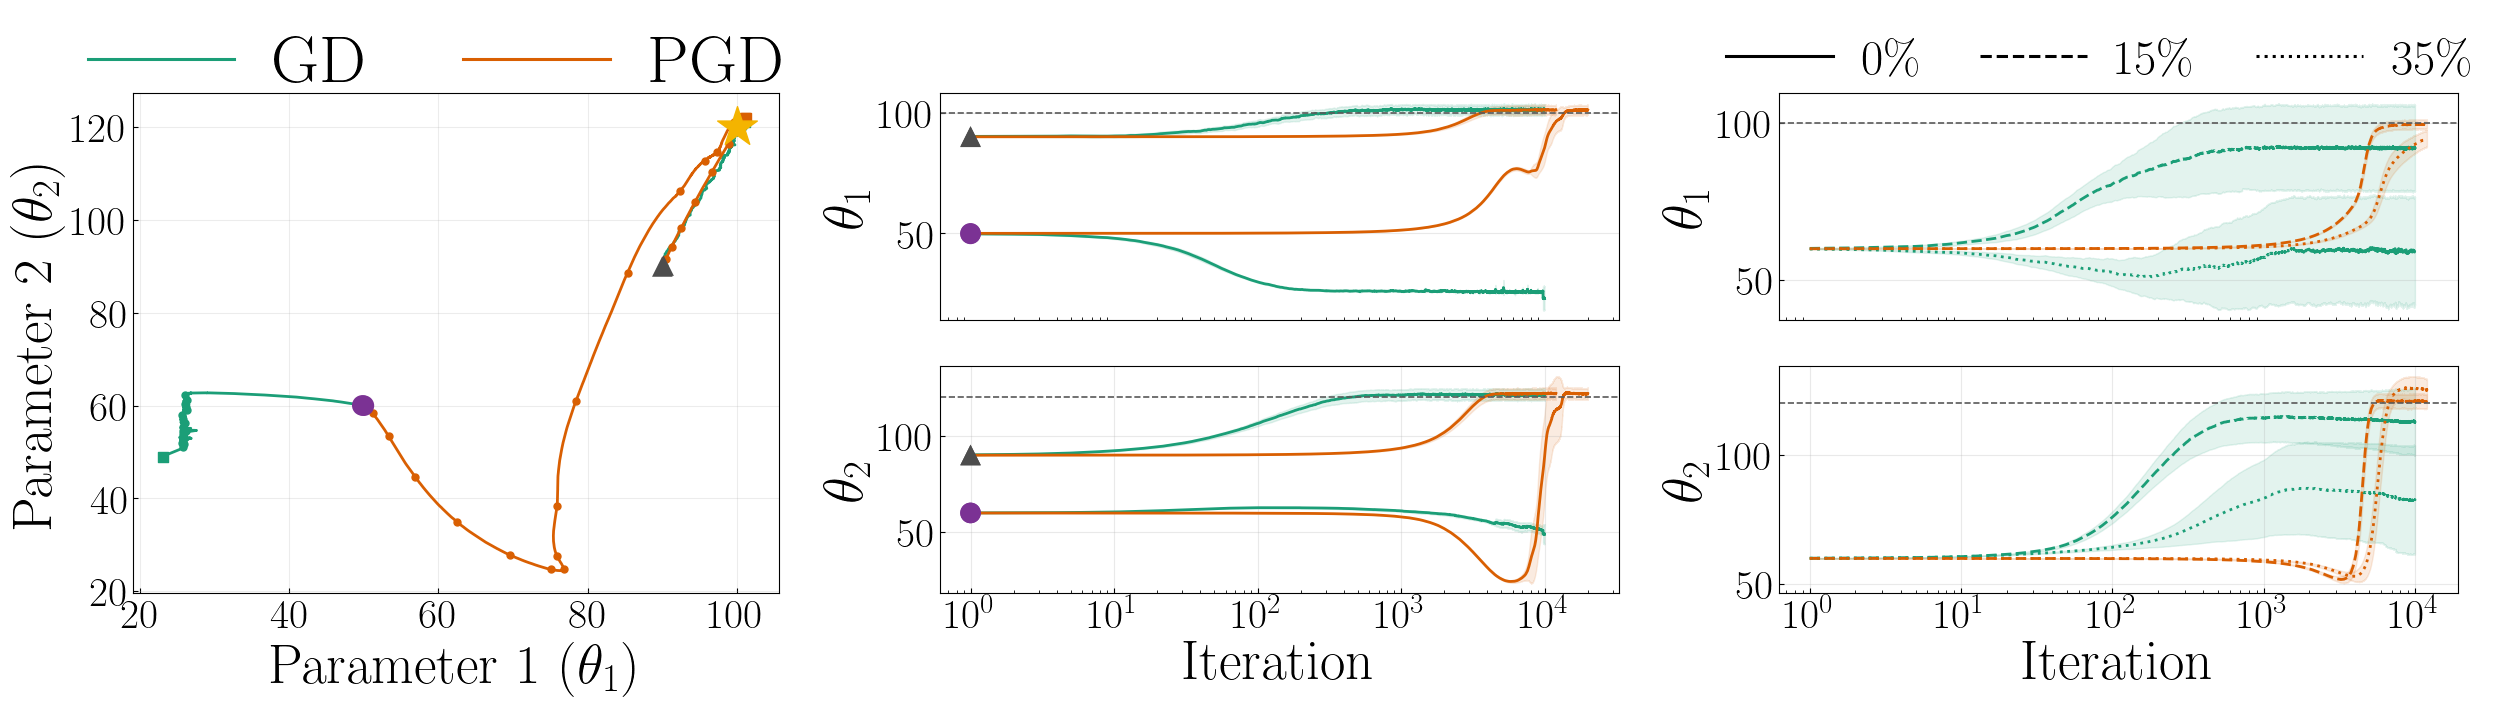

In [96]:
required_inputs = [*clean_npz_paths, *corruption_npz_paths]
missing_inputs = [path for path in required_inputs if not path.exists()]

if not missing_inputs:
    fig = make_lv_five_panel_summary(
        clean_npz_paths=clean_npz_paths,
        corruption_npz_paths=corruption_npz_paths,
        output_path=None,
        figsize=SUMMARY_FIGSIZE,
        dpi=DPI,
        se_scale=1.96,
    )
    fig.savefig(OUTPUT_FIGURE, bbox_inches="tight")
    print(f"Saved figure to {OUTPUT_FIGURE}")
    display(fig)
else:
    print(
        f"Figure not rendered because {len(missing_inputs)} source input(s) are missing: "
        + ", ".join(str(path) for path in missing_inputs)
    )


In [97]:
# Figures render inline in the previous cell and are also saved to OUTPUT_FIGURE.


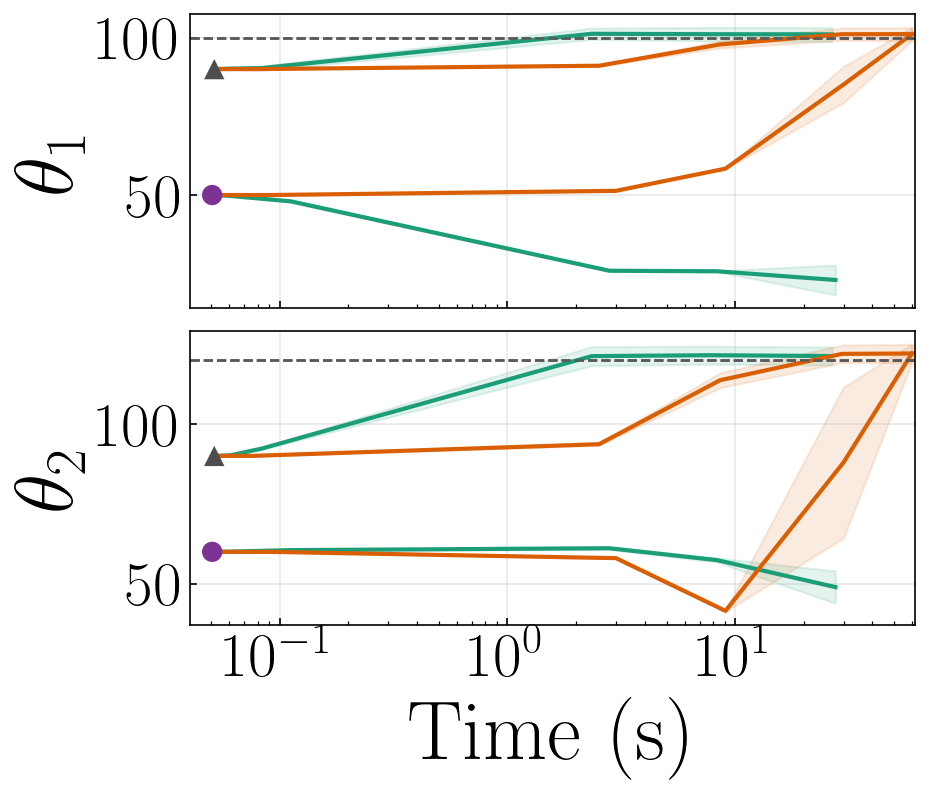

In [98]:
lv_time_budget_paths = {
    "50, 60": [
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_50_60_10.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_50_60_1000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_50_60_3000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_50_60_10000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_50_60_20000.npz"),
    ],
    "90, 90": [
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_90_90_10.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_90_90_1000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_90_90_3000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_90_90_10000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_90_90_20000.npz"),
    ],
}

def make_lv_theta_vs_time_budget_plot(path_map, output_path=None, se_scale=1.96, init_time_factor=0.85):
    init_styles = {
        "50, 60": {"marker": "o", "init_color": "#7B3294"},
        "90, 90": {"marker": "^", "init_color": "#4D4D4D"},
    }

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, axes = plt.subplots(2, 1, figsize=(6.3, 5.4), dpi=150, sharex=True)
        theta_true = None
        global_max_time = 0.0
        left_limit = np.inf

        for init_label, paths in path_map.items():
            style = init_styles.get(init_label, {"marker": "o", "init_color": "#4D4D4D"})
            sgd_time = []
            pgd_time = []
            sgd_theta = []
            pgd_theta = []
            theta0 = None
            sgd_theta_se = []
            pgd_theta_se = []

            for npz_path in paths:
                data = _load_npz_dict(npz_path)
                theta_true = np.asarray(data["theta_true"], dtype=float)
                theta0 = np.asarray(data["theta0"], dtype=float)
                sgd_time.append(float(np.asarray(data["sgd_elapsed_mean"], dtype=float)))
                pgd_time.append(float(np.asarray(data["pgd_elapsed_mean"], dtype=float)))
                sgd_theta.append(np.asarray(data["sgd_theta_mean"], dtype=float)[:2])
                pgd_theta.append(np.asarray(data["pgd_theta_mean"], dtype=float)[:2])
                sgd_theta_se.append(np.asarray(data["sgd_theta_se"], dtype=float)[:2])
                pgd_theta_se.append(np.asarray(data["pgd_theta_se"], dtype=float)[:2])

            sgd_time = np.asarray(sgd_time, dtype=float)
            pgd_time = np.asarray(pgd_time, dtype=float)
            sgd_theta = np.asarray(sgd_theta, dtype=float)
            pgd_theta = np.asarray(pgd_theta, dtype=float)
            sgd_theta_se = np.asarray(sgd_theta_se, dtype=float)
            pgd_theta_se = np.asarray(pgd_theta_se, dtype=float)

            global_max_time = max(global_max_time, float(np.max(sgd_time)), float(np.max(pgd_time)))
            sgd_order = np.argsort(sgd_time)
            pgd_order = np.argsort(pgd_time)
            init_time = init_time_factor * min(float(np.min(sgd_time)), float(np.min(pgd_time)))
            left_limit = min(left_limit, 0.8 * init_time)

            for param_idx, ax in enumerate(axes):
                sgd_plot_time = np.concatenate(([init_time], sgd_time[sgd_order]))
                sgd_plot_theta = np.concatenate(([theta0[param_idx]], sgd_theta[sgd_order, param_idx]))
                pgd_plot_time = np.concatenate(([init_time], pgd_time[pgd_order]))
                pgd_plot_theta = np.concatenate(([theta0[param_idx]], pgd_theta[pgd_order, param_idx]))

                ax.plot(
                    sgd_plot_time,
                    sgd_plot_theta,
                    color=COLORS["gd"],
                    linewidth=2.0,
                    marker=None,
                )
                ax.fill_between(
                    sgd_time[sgd_order],
                    sgd_theta[sgd_order, param_idx] - se_scale * sgd_theta_se[sgd_order, param_idx],
                    sgd_theta[sgd_order, param_idx] + se_scale * sgd_theta_se[sgd_order, param_idx],
                    color=COLORS["gd"],
                    alpha=0.12,
                )
                ax.plot(
                    pgd_plot_time,
                    pgd_plot_theta,
                    color=COLORS["pgd"],
                    linewidth=2.0,
                    marker=None,
                )
                ax.fill_between(
                    pgd_time[pgd_order],
                    pgd_theta[pgd_order, param_idx] - se_scale * pgd_theta_se[pgd_order, param_idx],
                    pgd_theta[pgd_order, param_idx] + se_scale * pgd_theta_se[pgd_order, param_idx],
                    color=COLORS["pgd"],
                    alpha=0.12,
                )
                ax.scatter(
                    init_time,
                    theta0[param_idx],
                    color=style["init_color"],
                    marker=style["marker"],
                    edgecolors="none",
                    linewidths=0.0,
                    s=95,
                    zorder=6,
                )
                ax.axhline(float(theta_true[param_idx]), color="0.35", linestyle="--", linewidth=1.2)
                ax.set_ylabel(rf"$\theta_{param_idx + 1}$")
                ax.grid(True, which="major", alpha=0.28, linewidth=0.8)

        for ax in axes:
            ax.set_xscale("log")
            ax.set_xlim(left_limit, global_max_time * 1.03)

        axes[-1].set_xlabel("Time (s)")
        fig.tight_layout()
        return _save_figure(fig, output_path)


make_lv_theta_vs_time_budget_plot(
    lv_time_budget_paths,
    output_path=FIGURES_DIR / "lv_theta_vs_time_budget.pdf",
)


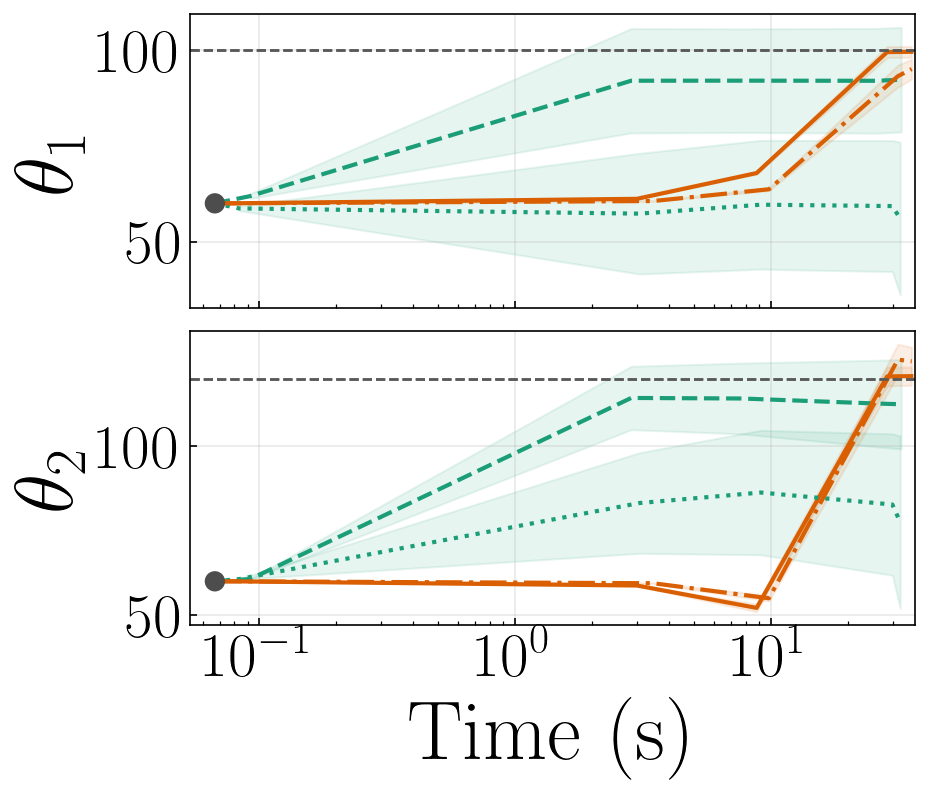

In [99]:
lv_corruption_time_paths = {
    "c15": [
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c15_10.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c15_1000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c15_3000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c15_10000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c15_12000.npz"),
    ],
    "c35": [
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c35_10.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c35_1000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c35_3000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c35_10000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c35_12000.npz"),
    ],
}

def make_lv_corruption_theta_vs_time_plot(path_map, output_path=None, se_scale=1.96, init_time_factor=0.85):
    line_styles = {"c15": ("--", "-"), "c35": (":", "-.")}

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, axes = plt.subplots(2, 1, figsize=(6.3, 5.4), dpi=150, sharex=True)
        theta_true = None
        theta0_shared = None
        shared_init_time = None
        global_max_time = 0.0
        left_limit = np.inf

        for label, paths in path_map.items():
            sgd_time = []
            pgd_time = []
            sgd_theta = []
            pgd_theta = []
            sgd_theta_se = []
            pgd_theta_se = []
            theta0 = None

            for npz_path in paths:
                data = _load_npz_dict(npz_path)
                theta_true = np.asarray(data["theta_true"], dtype=float)
                theta0 = np.asarray(data["theta0"], dtype=float)
                theta0_shared = theta0
                sgd_time.append(float(np.asarray(data["sgd_elapsed_mean"], dtype=float)))
                pgd_time.append(float(np.asarray(data["pgd_elapsed_mean"], dtype=float)))
                sgd_theta.append(np.asarray(data["sgd_theta_mean"], dtype=float)[:2])
                pgd_theta.append(np.asarray(data["pgd_theta_mean"], dtype=float)[:2])
                sgd_theta_se.append(np.asarray(data["sgd_theta_se"], dtype=float)[:2])
                pgd_theta_se.append(np.asarray(data["pgd_theta_se"], dtype=float)[:2])

            sgd_time = np.asarray(sgd_time, dtype=float)
            pgd_time = np.asarray(pgd_time, dtype=float)
            sgd_theta = np.asarray(sgd_theta, dtype=float)
            pgd_theta = np.asarray(pgd_theta, dtype=float)
            sgd_theta_se = np.asarray(sgd_theta_se, dtype=float)
            pgd_theta_se = np.asarray(pgd_theta_se, dtype=float)
            if len(sgd_time) == 0 or len(pgd_time) == 0:
                continue

            global_max_time = max(global_max_time, float(np.max(sgd_time)), float(np.max(pgd_time)))
            sgd_order = np.argsort(sgd_time)
            pgd_order = np.argsort(pgd_time)
            init_time = init_time_factor * min(float(np.min(sgd_time)), float(np.min(pgd_time)))
            left_limit = min(left_limit, 0.8 * init_time)
            if shared_init_time is None:
                shared_init_time = init_time
            line_init_time = shared_init_time
            sgd_ls, pgd_ls = line_styles.get(label, ("--", "-"))

            for param_idx, ax in enumerate(axes):
                sgd_plot_time = np.concatenate(([line_init_time], sgd_time[sgd_order]))
                sgd_plot_theta = np.concatenate(([theta0[param_idx]], sgd_theta[sgd_order, param_idx]))
                pgd_plot_time = np.concatenate(([line_init_time], pgd_time[pgd_order]))
                pgd_plot_theta = np.concatenate(([theta0[param_idx]], pgd_theta[pgd_order, param_idx]))

                ax.plot(
                    sgd_plot_time,
                    sgd_plot_theta,
                    color=COLORS["gd"],
                    linestyle=sgd_ls,
                    linewidth=2.0,
                    marker=None,
                )
                ax.fill_between(
                    sgd_time[sgd_order],
                    sgd_theta[sgd_order, param_idx] - se_scale * sgd_theta_se[sgd_order, param_idx],
                    sgd_theta[sgd_order, param_idx] + se_scale * sgd_theta_se[sgd_order, param_idx],
                    color=COLORS["gd"],
                    alpha=0.10,
                )
                ax.plot(
                    pgd_plot_time,
                    pgd_plot_theta,
                    color=COLORS["pgd"],
                    linestyle=pgd_ls,
                    linewidth=2.0,
                    marker=None,
                )
                ax.fill_between(
                    pgd_time[pgd_order],
                    pgd_theta[pgd_order, param_idx] - se_scale * pgd_theta_se[pgd_order, param_idx],
                    pgd_theta[pgd_order, param_idx] + se_scale * pgd_theta_se[pgd_order, param_idx],
                    color=COLORS["pgd"],
                    alpha=0.10,
                )
                ax.axhline(float(theta_true[param_idx]), color="0.35", linestyle="--", linewidth=1.2)
                ax.set_ylabel(rf"$\theta_{param_idx + 1}$")
                ax.grid(True, which="major", alpha=0.28, linewidth=0.8)

        if theta0_shared is not None and shared_init_time is not None:
            for param_idx, ax in enumerate(axes):
                ax.scatter(
                    shared_init_time,
                    theta0_shared[param_idx],
                    color="#4D4D4D",
                    marker="o",
                    edgecolors="none",
                    linewidths=0.0,
                    s=95,
                    zorder=6,
                )

        for ax in axes:
            ax.set_xscale("log")
            ax.set_xlim(left_limit, global_max_time * 1.03)

        axes[-1].set_xlabel("Time (s)")
        fig.tight_layout()
        return _save_figure(fig, output_path)


make_lv_corruption_theta_vs_time_plot(
    lv_corruption_time_paths,
    output_path=FIGURES_DIR / "lv_corruption_theta_vs_time.pdf",
)


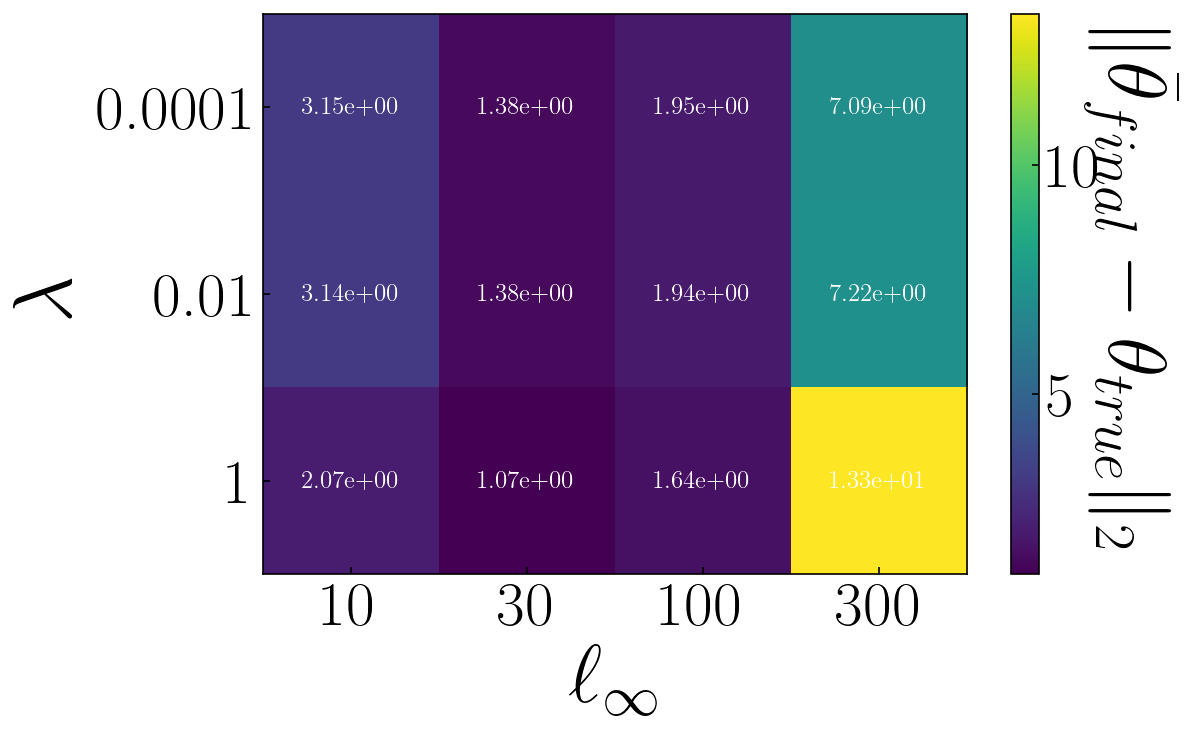

In [100]:
# LV theta-error heatmap from ablations/lv_heatmap
import re


def _parse_heatmap_float(value):
    return float(value.replace("p", "."))


def _draw_theta_error_heatmap(error_grid, ell_values, lambda_values, output_path):
    masked_grid = np.ma.masked_invalid(error_grid)
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad(color="lightgray")

    figure_height = 5.0 if len(lambda_values) > 1 else 2.8
    heatmap_dpi = 150
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(8.0, figure_height), dpi=heatmap_dpi)
        im = ax.imshow(masked_grid, cmap=cmap, aspect="auto")

        ax.set_xticks(np.arange(len(ell_values)))
        ax.set_yticks(np.arange(len(lambda_values)))
        ax.set_xticklabels([f"{ell:g}" for ell in ell_values])
        ax.set_yticklabels([f"{lam:g}" for lam in lambda_values])
        ax.set_xlabel(r"$\ell_{\infty}$")
        ax.set_ylabel(r"$\lambda$")
        ax.grid(False)

        for i in range(error_grid.shape[0]):
            for j in range(error_grid.shape[1]):
                if np.isfinite(error_grid[i, j]):
                    ax.text(
                        j,
                        i,
                        f"{error_grid[i, j]:.2e}",
                        ha="center",
                        va="center",
                        color="white",
                        fontsize=12,
                    )

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label(r"$\|\bar{\theta}_{final} - \theta_{true}\|_2$", rotation=270, labelpad=35)
        fig.tight_layout()
        fig.savefig(output_path, bbox_inches="tight")
        return fig


def make_lv_theta_error_heatmap(results_dir, output_path):
    results_dir = Path(results_dir)
    filename_pattern = re.compile(
        r"lotka_volterra_lengthscale_regularization_grid_pgd_ell_min_"
        r"(?P<ell>[^_]+)_lambda_(?P<lam>[^_]+)\.npz$"
    )

    error_by_cell = {}
    ell_values = set()
    lambda_values = set()

    for npz_path in sorted(results_dir.glob("lotka_volterra_lengthscale_regularization_grid_pgd_ell_min_*_lambda_*.npz")):
        match = filename_pattern.match(npz_path.name)
        if match is None:
            continue

        ell = _parse_heatmap_float(match.group("ell"))
        lam = _parse_heatmap_float(match.group("lam"))
        data = _load_npz_dict(npz_path)
        theta_true = np.asarray(data["theta_true"], dtype=float)
        theta_final = np.asarray(data["pgd_theta_mean"], dtype=float)
        theta_error = float(np.linalg.norm(theta_final - theta_true))

        error_by_cell[(lam, ell)] = theta_error
        ell_values.add(ell)
        lambda_values.add(lam)

    if not error_by_cell:
        raise ValueError(f"No LV heatmap files found in {results_dir}")

    sorted_ells = np.asarray(sorted(ell_values), dtype=float)
    sorted_lambdas = np.asarray(sorted(lambda_values), dtype=float)
    error_grid = np.full((len(sorted_lambdas), len(sorted_ells)), np.nan, dtype=float)

    for i, lam in enumerate(sorted_lambdas):
        for j, ell in enumerate(sorted_ells):
            if (float(lam), float(ell)) in error_by_cell:
                error_grid[i, j] = error_by_cell[(float(lam), float(ell))]

    return _draw_theta_error_heatmap(error_grid, sorted_ells, sorted_lambdas, output_path)


lv_theta_error_fig = make_lv_theta_error_heatmap(
    ROOT / "ablations" / "lv_heatmap",
    FIGURES_DIR / "lv_theta_error_ablation.pdf",
)
lv_theta_error_fig